In [17]:
# Imports
from ModelsImplementations import deffuant, hk
from PlotUtils import plot_evolution_comparison

# Opinion Dynamics & Polarization

Ever wondered why people seem to get more extreme over time instead of finding middle ground? This project tries to explore this from a mathematical point of view.

We will model a population of agents each with opinions between $0$ and $1$.  Through simple interaction rules, we will see how consensus, polarization and fragmantation emerge. Will explore how different factors influence the results and the what role recommendation algorithms play in all of this.

### What we'll do

- Implement two mathematical models of opinion dynamics — **Deffuant** and **HK**
- Show how a single parameter controls whether society agrees or fragments
- Test what happens when we have various network structures
- Model the effect of algorithmic bias — what happens when an algorithm keeps showing you people who already agree with you
- Run experiments and measure polarization quantitatively

### Why it matters

What makes this interesting mathematically is that complex collective 
behavior sometimes emerges from extremely simple rules. Even if no agent is trying to polarize society, polarization can still appears as a natural consequence of bounded confidence. This is an example of 
what is called emergent behavior in complex systems.
At the end we will take a step back and look at the bigger picture. We will use the mathematical lens we have built (hopefully) to trace how the way opinions form and spread has changed throughout history - from local village conversations to global algorithmic feeds.

### Assumptions
TO-DO Fromat assumptions
- Throughout the whole project we assume uniform distribution for the initial opinions.


## The Deffuant Model

Each agent $i$ has an opinion $x_i \in [0, 1]$. At each step, two random agents meet. 
If they are close enough in opinion, then their opinions "move" toward each other:

$$x_i(t+1) = x_i(t) + \mu \cdot (x_j(t) - x_i(t))$$
$$x_j(t+1) = x_j(t) + \mu \cdot (x_i(t) - x_j(t))$$

If their opinions are too far apart, they don't influence each other so nothing happens.

| Symbol | Meaning |
|--------|---------|
| $x_i$ | Opinion of agent $i$, between 0 and 1 |
| $\varepsilon$ | How open-minded agents are - the confidence threshold |
| $\mu$ | How fast they move toward each other (usually 0.5) |



## The Hegselmann-Krause (HK) Model

Same idea as Deffuant. But in this case instead of two people meeting at a time, everyone updates simultaneously. Each agent moves to the average opinion of everyone within their confidence bound:

$$x_i(t+1) = \frac{1}{|B(i,t)|} \sum_{j \in B(i,t)} x_j(t)$$

where $B(i,t)$ is just the set of agents close enough to agent $i$:

$$B(i, t) = \{ j : |x_i(t) - x_j(t)| < \varepsilon \}$$

Think of it as the difference between having one conversation and 
scrolling through your entire social media feed where everyone absorbs 
their whole bubble at once.


## Visualizing Opinion Evolution
Let's see what the models actually look like before we anylize them.
The code below performs simulations for two models with values of $$ \varepsilon $$ varying.
Each line represents one agent's opinion over time. We can see how they either converge into one point, or drift apart into separate clusters.

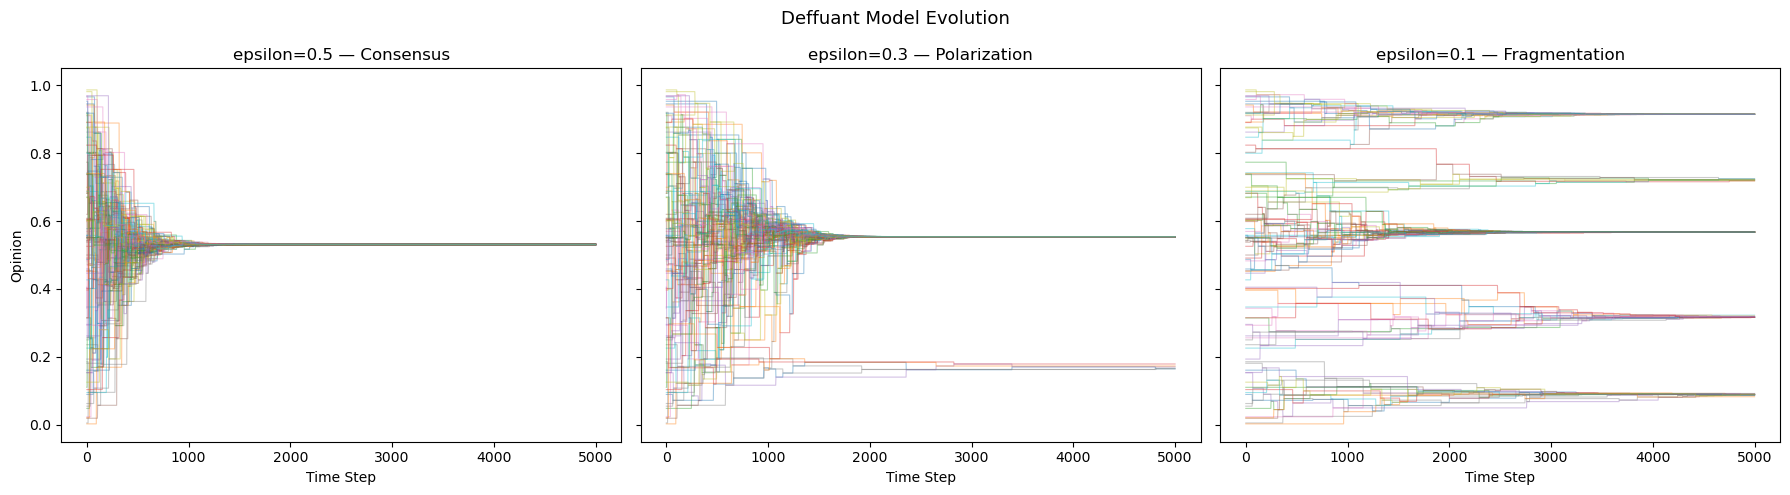

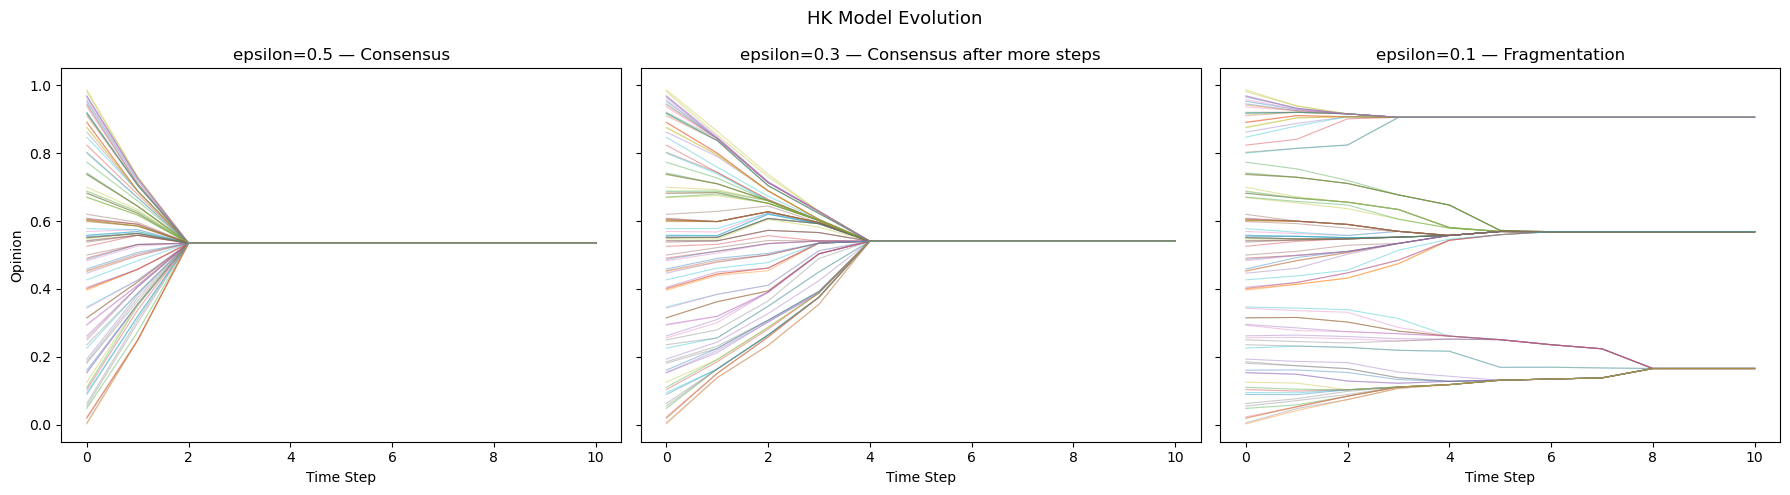

In [26]:
# Params
seed=63
stepsDeffuant = 5000
stepsHk = 10
numberOfAgents = 100
mu = 0.5

# Run Deffuant
hist_consensus = deffuant(numberOfAgents, 0.5, mu,stepsDeffuant, seed)
hist_polar     = deffuant(numberOfAgents, 0.3, mu,stepsDeffuant, seed)
hist_fragment  = deffuant(numberOfAgents, 0.1, mu,stepsDeffuant, seed)

plot_evolution_comparison(
    histories=[hist_consensus, hist_polar, hist_fragment],
    titles=[
        'epsilon=0.5 - Consensus',
        'epsilon=0.3 - Polarization',
        'epsilon=0.1 - Fragmentation'
    ],
    suptitle='Deffuant Model Evolution'
)

# Same for HK
hist_hk_consensus = hk(numberOfAgents, 0.5, stepsHk, seed)
hist_hk_polar     = hk(numberOfAgents, 0.3, stepsHk, seed)
hist_hk_fragment  = hk(numberOfAgents, 0.1, stepsHk, seed)
plot_evolution_comparison(
    histories=[hist_hk_consensus, hist_hk_polar, hist_hk_fragment],
    titles=[
        'epsilon=0.5 — Consensus',
        'epsilon=0.3 — Consensus after more steps',
        'epsilon=0.1 — Fragmentation'
    ],
    suptitle='HK Model Evolution'
)


Some things that can be seen from the plot.

In the **Deffuant model** the three regimes are clearly visible:
- $\varepsilon = 0.5$ -> full consensus
- $\varepsilon = 0.3$ -> polarization into two stable camps
- $\varepsilon = 0.1$ -> fragmentation into several clusters

The **HK model** converges in under significantly less steps across all configurations. This is expected since all $n$ agents update simultaneously rather than two at a time.

There is one very notable difference: at $\varepsilon = 0.3$, Deffuant polarizes while HK reaches consensus. Synchronous updates allow opinion bridges to form before clusters isolate. This result holds regardless of population size.

$$\begin{array}{|c|c|c|}
\hline
\varepsilon & \text{Deffuant} & \text{HK} \\
\hline
0.5 & \text{Consensus} & \text{Consensus} \\
0.3 & \text{Polarization} & \text{Consensus} \\
0.1 & \text{Fragmentation} & \text{Fragmentation} \\
\hline
\end{array}$$

## The Critical Threshold - The Importance Of $\varepsilon$

The confidence threshold $\varepsilon$ is the most important parameter in both of the models. Let's see how actually it affects the outcome.

We can do this by running the simulation many times for different values of $\varepsilon \in [0, 1]$ and recording how many clusters form each time.
TO-DO - Implement metrics function to measure polarization in some way. Run the simulations and check the results. Check for formal proof.
The number of final clusters $k$ as a function of $\varepsilon$ follows a pattern:

$$k(\varepsilon) = \left\lfloor \frac{1}{2\varepsilon} \right\rfloor$$

This tells us that the population splits into approximately $\frac{1}{2\varepsilon}$ groups.
For example:
- $\varepsilon = 0.5$ -> $k \approx 1$ (consensus)
- $\varepsilon = 0.25$ -> $k \approx 2$ (polarization)
- $\varepsilon = 0.1$ -> $k \approx 5$ (fragmentation)

**Note:** We only test $\varepsilon \in (0, 0.5]$ because for a uniform 
distribution on $[0,1]$ any $\varepsilon \geq 0.5$ guarantees full consensus. This is true because the two most extreme possible opinions ($0$ and $1$) are always within each other's confidence bound. So above this threshold we will always get consesus as a result even though the number of steps needed to converge is different.

## Deffuant vs HK - Same Parameters, Different Worlds
TO-DO Compare the two models by their nature, using same parameters. Explain differences. Add simulations again

## Adding Network Structure

TO-DO Explore how the results change when the structure of connections is different. Use graphs to model this, find how to represent it visually. And how to implement it

## The Echo Chamber - How Algorithmic Bias Affects Opinions

TO-DO Try to simulate algorithmic bias and see how this influences the results. In some way to simulate the influence of social media recommendation algorithms

## Conclusions
TO-DO Fill with conclusions, obviously

## References
TO-DO Fill references along the way. Maybe check proper format before final commit.

- Deffuant, G., Neau, D., Amblard, F., & Weisbuch, G. (2000). *Mixing beliefs among interacting agents.* Advances in Complex Systems, 3(1-4), 87-98.
- Hegselmann, R., & Krause, U. (2002). *Opinion dynamics and bounded confidence: models, analysis and simulation.* Journal of Artificial Societies and Social Simulation, 5(3).